# 04 - MVTec Dataset Understanding

**Purpose:** Understand dataset structure before ML loading.

**Expected output:** Folder check, class guide, dataset counts, sample image grid, and ground-truth mask overlay.

**Platform connection:** The model learns normal bottle appearance from `train/good` and evaluates defect classes from `test/`.


In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
IMAGE_SIZE = (256, 256)
LABELS = ["good", "broken_large", "broken_small", "contamination"]


def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def first_image(label="contamination", split="test"):
    folder = BOTTLE_DIR / split / label
    images = sorted(folder.glob("*.png"))
    if not images:
        raise FileNotFoundError(f"No images found in {folder}")
    return images[0]


def show_grid(items, cols=4, figsize=(14, 7), suptitle=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, image, cmap = item
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Project root:", PROJECT_ROOT)
print("MVTec bottle folder exists:", BOTTLE_DIR.exists())


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
MVTec bottle folder exists: True


## Folder Structure Check


In [2]:
expected_paths = [
    BOTTLE_DIR / "train" / "good",
    BOTTLE_DIR / "test" / "good",
    BOTTLE_DIR / "test" / "broken_large",
    BOTTLE_DIR / "test" / "broken_small",
    BOTTLE_DIR / "test" / "contamination",
    BOTTLE_DIR / "ground_truth" / "broken_large",
    BOTTLE_DIR / "ground_truth" / "broken_small",
    BOTTLE_DIR / "ground_truth" / "contamination",
]
display(pd.DataFrame([{"folder": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists(), "png_count": len(list(path.glob("*.png"))) if path.exists() else 0} for path in expected_paths]))


,folder,exists,png_count
0,data\raw\mvtec_anomaly_detection\bottle\train\...,True,209
1,data\raw\mvtec_anomaly_detection\bottle\test\good,True,20
2,data\raw\mvtec_anomaly_detection\bottle\test\b...,True,20
3,data\raw\mvtec_anomaly_detection\bottle\test\b...,True,22
4,data\raw\mvtec_anomaly_detection\bottle\test\c...,True,21
5,data\raw\mvtec_anomaly_detection\bottle\ground...,True,20
6,data\raw\mvtec_anomaly_detection\bottle\ground...,True,22
7,data\raw\mvtec_anomaly_detection\bottle\ground...,True,21


## Class Guide


In [3]:
display(pd.DataFrame([
    {"label": "good", "meaning": "normal bottle image", "used_for": "normal training and pass cases", "mask_expected": False},
    {"label": "broken_large", "meaning": "large break/crack defect", "used_for": "defective test case", "mask_expected": True},
    {"label": "broken_small", "meaning": "small break/chip defect", "used_for": "defective test case", "mask_expected": True},
    {"label": "contamination", "meaning": "foreign material/contamination", "used_for": "defective test case", "mask_expected": True},
]))


,label,meaning,used_for,mask_expected
0,good,normal bottle image,normal training and pass cases,False
1,broken_large,large break/crack defect,defective test case,True
2,broken_small,small break/chip defect,defective test case,True
3,contamination,foreign material/contamination,defective test case,True


## Counts And Visual Samples


,split,label,count
0,train,good,209
1,test,good,20
2,test,broken_large,20
3,test,broken_small,22
4,test,contamination,21


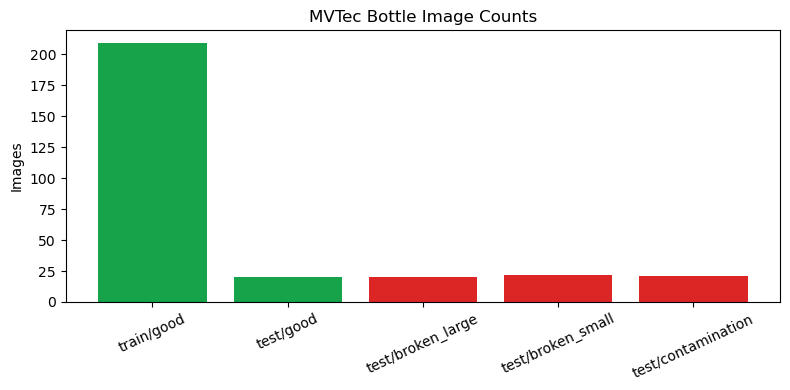

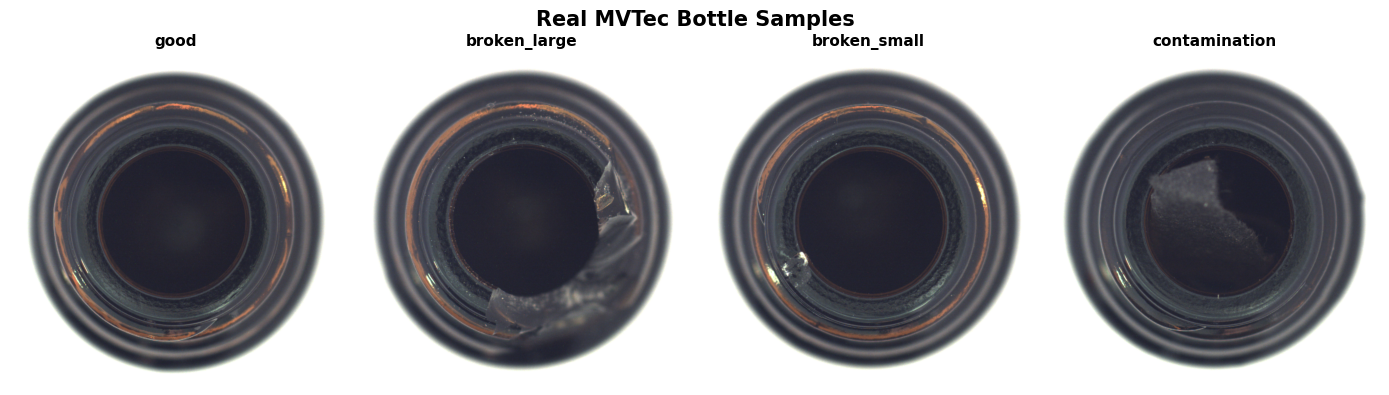

In [4]:
rows = []
for split in ["train", "test"]:
    labels = ["good"] if split == "train" else LABELS
    for label in labels:
        folder = BOTTLE_DIR / split / label
        rows.append({"split": split, "label": label, "count": len(list(folder.glob("*.png"))) if folder.exists() else 0})
counts_df = pd.DataFrame(rows)
display(counts_df)
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = counts_df.assign(group=counts_df["split"] + "/" + counts_df["label"])
ax.bar(plot_df["group"], plot_df["count"], color=["#16a34a" if "good" in g else "#dc2626" for g in plot_df["group"]])
ax.set_title("MVTec Bottle Image Counts")
ax.set_ylabel("Images")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
show_grid([(label, read_rgb(first_image(label, "test")), None) for label in LABELS], cols=4, figsize=(14, 4), suptitle="Real MVTec Bottle Samples")


## Ground-Truth Mask Overlay


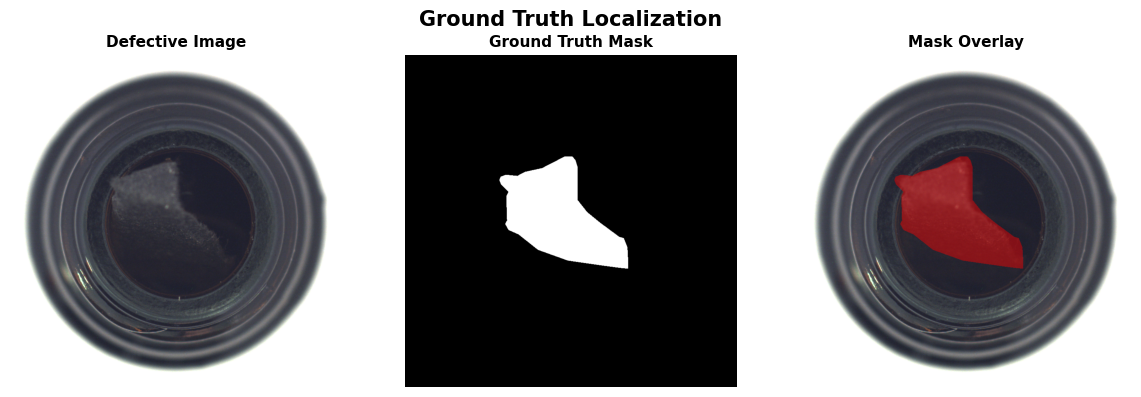

,label,image,mask_exists,mask_area_percent
0,broken_large,000.png,True,10.89
1,broken_small,000.png,True,0.88
2,contamination,000.png,True,7.25


In [5]:
mask_rows = []
for label in ["broken_large", "broken_small", "contamination"]:
    image_path = first_image(label, "test")
    mask_path = BOTTLE_DIR / "ground_truth" / label / f"{image_path.stem}_mask.png"
    image = read_rgb(image_path)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask_rows.append({"label": label, "image": image_path.name, "mask_exists": mask is not None, "mask_area_percent": round(float(np.mean(mask > 0) * 100), 2) if mask is not None else None})
    if label == "contamination" and mask is not None:
        red = np.zeros_like(image)
        red[:, :, 0] = 255
        overlay = np.where(mask[..., None] > 0, (0.55 * image + 0.45 * red).astype(np.uint8), image)
        show_grid([("Defective Image", image, None), ("Ground Truth Mask", mask, "gray"), ("Mask Overlay", overlay, None)], cols=3, figsize=(12, 4), suptitle="Ground Truth Localization")
display(pd.DataFrame(mask_rows))


## Dataset Risk Audit

This checks whether the dataset has enough structure for anomaly detection, classification, and localization.


In [6]:
audit_rows = []
train_good_count = len(list((BOTTLE_DIR / "train" / "good").glob("*.png")))
test_counts = {label: len(list((BOTTLE_DIR / "test" / label).glob("*.png"))) for label in LABELS}
mask_counts = {label: len(list((BOTTLE_DIR / "ground_truth" / label).glob("*.png"))) for label in LABELS if label != "good"}

audit_rows.append({"check": "normal training images available", "value": train_good_count, "status": "OK" if train_good_count > 0 else "MISSING"})
for label, count in test_counts.items():
    audit_rows.append({"check": f"test images for {label}", "value": count, "status": "OK" if count > 0 else "MISSING"})
for label, count in mask_counts.items():
    expected = test_counts[label]
    audit_rows.append({"check": f"ground truth masks for {label}", "value": f"{count}/{expected}", "status": "OK" if count == expected else "CHECK"})

display(pd.DataFrame(audit_rows))


,check,value,status
0,normal training images available,209,OK
1,test images for good,20,OK
2,test images for broken_large,20,OK
3,test images for broken_small,22,OK
4,test images for contamination,21,OK
5,ground truth masks for broken_large,20/20,OK
6,ground truth masks for broken_small,22/22,OK
7,ground truth masks for contamination,21/21,OK


## Validation Outcome

- The dataset follows normal-only training and mixed test evaluation.
- Defect masks support localization evaluation.
- The labels map directly to the app's defect categories.
